In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve, precision_recall_curve)

In [3]:
path = 'bank-additional/bank-additional/bank-additional-full.csv'
df = pd.read_csv(path, sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]

def report_metrics(y_true, y_probs, threshold, label_name):
    preds = (y_probs >= threshold).astype(int)
    cm = confusion_matrix(y_true, preds)
    tn, fp, fn, tp = cm.ravel()
    
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    
    print(f"\n--- Metrics for {label_name} (Threshold: {threshold}) ---")
    print(f"Confusion Matrix:\n{cm}")
    print(classification_report(y_true, preds))
    print(f"Sensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")

report_metrics(y_test, probs, 0.5, "Standard Threshold")

precision, recall, thresholds = precision_recall_curve(y_test, probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
opt_threshold = thresholds[np.argmax(f1_scores)]
report_metrics(y_test, probs, round(opt_threshold, 2), "Optimized Threshold")


--- Metrics for Standard Threshold (Threshold: 0.5) ---
Confusion Matrix:
[[8902  242]
 [ 677  476]]
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      9144
           1       0.66      0.41      0.51      1153

    accuracy                           0.91     10297
   macro avg       0.80      0.69      0.73     10297
weighted avg       0.90      0.91      0.90     10297

Sensitivity (Recall): 0.4128
Specificity: 0.9735

--- Metrics for Optimized Threshold (Threshold: 0.24) ---
Confusion Matrix:
[[8482  662]
 [ 343  810]]
              precision    recall  f1-score   support

           0       0.96      0.93      0.94      9144
           1       0.55      0.70      0.62      1153

    accuracy                           0.90     10297
   macro avg       0.76      0.82      0.78     10297
weighted avg       0.92      0.90      0.91     10297

Sensitivity (Recall): 0.7025
Specificity: 0.9276


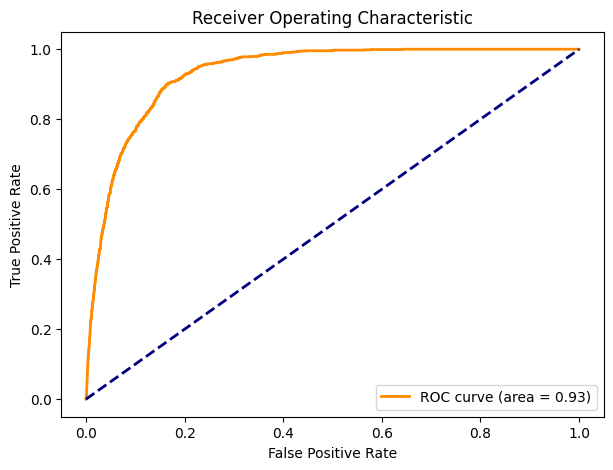

Final ROC-AUC Score: 0.9328


In [6]:
auc_score = roc_auc_score(y_test, probs)
fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

print(f"Final ROC-AUC Score: {auc_score:.4f}")

In [7]:
output_df = pd.DataFrame({
    'RecordId': range(len(probs)),
    'Probability(yes)': probs,
    'PredictedLabel': (probs >= 0.5).astype(int)
})

output_df.to_csv('probabilities.csv', index=False)